In the previous part of the tutorial we looked at the effect of distributed renewable generation on the distribution grid, and how storage and peak shaving reduces this effect. In this tutorial we focus on evaluating the positive influence of energy hubs.

An energy hub is a smartly-controlled decentralized energy system within a defined area coordinating their generation, storage, conversion, and consumption to balance the local demand and collaborating towards a common goal.

One of the main advantages of an energy hub is the flexibility of generation and demand. Generation can be tailored to the more specific local needs, and demand can be handled by peak shifting (cooperation) and appropriate storage strategy.

First of all lets install the necessary packages for the visualizations in this tutorial by running the next cell:

In [1]:
%pip install -q ipywidgets
%matplotlib widget

Note: you may need to restart the kernel to use updated packages.


In [2]:
from illuminator.engine import Simulation
import functions_T3
import pandas as pd
import nest_asyncio
nest_asyncio.apply()

What can we use to evaluate the hubs?
In this step we chose our KPIs; CO2 emissions as a measure for sustainability, cost as a measure of efficiency and grid congestion as a measure for distribution efficiency.

Let's re-run the tutorial 3 simulation in it's worst case scenario, no renewables nor measures for grid congestion, this time we have 100 houses 

In [3]:
%%capture
CONFIG_FILE = 'data\Tutorial_physical_congestion_RES_bat.yaml'
simulation_RES_Bat = Simulation(CONFIG_FILE)
simulation_RES_Bat.set_model_param(model_name='CSVload', parameter='file_path', value='data\load_data.txt')
simulation_RES_Bat.set_model_param(model_name='CSV_pv', parameter='file_path',
                                   value='data\pv_data_Rotterdam_NL-15min.txt')
simulation_RES_Bat.set_model_param(model_name='CSV_wind', parameter='file_path', value='data\winddata_NL.txt')

new_settings = {'Wind1': {'p_rated': 0},
                'Load1': {'houses': 100},
                'PV1': {'cap': 20000},
                'Battery1': {'max_p': 40, 'min_p': -40, 'soc_min': 10, 'soc_max': 90},
                'Controller1': {'battery_active': False,'max_p': 40},
                'Grid1':{'connection_capacity' : 150, 'tolerance_limit': 0.67, 'critical_limit': 0.9},
                }

simulation_RES_Bat.edit_models(new_settings)

# you can switch between the selected days 2012-02-01 and 2012-07-06 by changing the date in the two lines below for better readibility it is advised to keep the observed time slot at 1 day
simulation_RES_Bat.set_scenario_param('start_time', '2012-02-01 00:00:00')
simulation_RES_Bat.set_scenario_param('end_time', '2012-02-01 23:45:00')

# run the simulation
simulation_RES_Bat.run()

2026-01-15 11:10:00.965 | INFO     | mosaik.async_scenario:start:420 - Starting "Collector" as "Collector-0" ...
2026-01-15 11:10:05.096 | INFO     | mosaik.async_scenario:start:420 - Starting "CSVload" as "CSVload-0" ...
2026-01-15 11:10:06.006 | WARNING  | mosaik.async_scenario:user_warning:342 - c:\Users\ainet\miniconda3\envs\ill-dev\Lib\site-packages\mosaik\adapters.py:98: UserWarning: Simulator CSVload-0 is using an outdated API version, namely 1. It should still work. You can suppress this warning by adding an explicit API version for this simulator in your SimConfig.
2026-01-15 11:10:06.016 | INFO     | mosaik.async_scenario:start:420 - Starting "CSV_pv" as "CSV_pv-0" ...
2026-01-15 11:10:06.525 | WARNING  | mosaik.async_scenario:user_warning:342 - c:\Users\ainet\miniconda3\envs\ill-dev\Lib\site-packages\mosaik\adapters.py:98: UserWarning: Simulator CSV_pv-0 is using an outdated API version, namely 1. It should still work. You can suppress this warning by adding an explicit API 

As we now don't generate with any renewables of our own we are tied to the CO2 production of the Netherlands' grid energy mix. We apply a (variable) CO2 calculation to the power demand, this will be the first KPI.  

We do a similar process to find the effect on cost of electricity, using the intraday market prices for the energy from the grid:

Total CO2 Emissions:        171.65 kg
                            0.17 tonnes
  Total Cost:               €64.75

✓ Results saved to: electricity_cost_results.csv

⚠ Grid congestion detected!
   Congestion events: 2


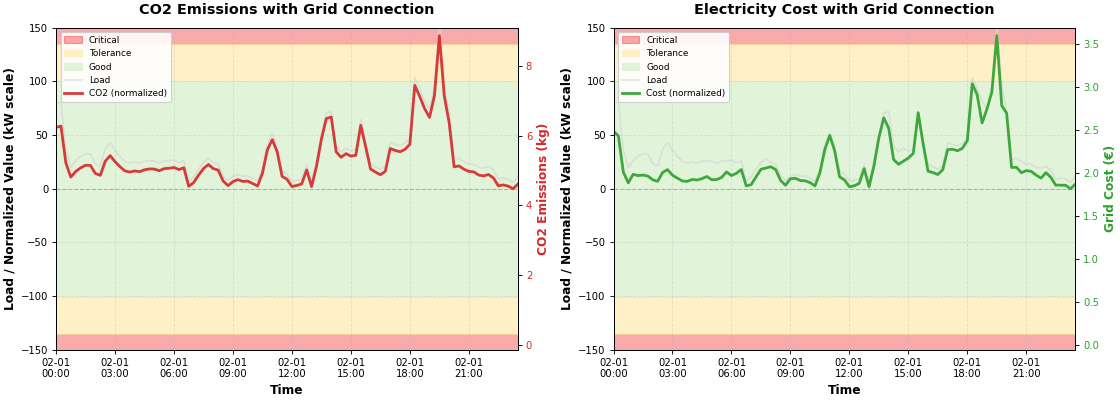

In [4]:
from complete_co2_workflow import align_dates_and_calculate_co2

co2_results = align_dates_and_calculate_co2(
    generation_file='data\GENERATION_PER_TYPE_20251125-20251202.csv',
    consumption_file='out_Tutorial_RES_Bat.csv',
    consumption_column='Controller1.dump',
    consumption_date_column='date',
    output_csv='co2_results.csv'
)

# Step 2: Calculate electricity costs
from electricity_cost_calculator import calculate_electricity_cost

cost_results = calculate_electricity_cost(
    price_file='data\GUI_ENERGY_PRICES_202511272300-202511282300.csv',
    consumption_file='out_Tutorial_RES_Bat.csv',
    consumption_column='Controller1.dump',
    consumption_date_column='date',
    price_date_column='MTU (CET/CEST)',
    price_column='Day-ahead Price (EUR/MWh)',
    output_csv='electricity_cost_results.csv'
)

from combined_analysis_plots import plot_combined_analysis

fig, (ax1, ax2) = plot_combined_analysis(
    co2_results_file='co2_results.csv',
    cost_results_file='electricity_cost_results.csv',
    consumption_file='out_Tutorial_RES_Bat.csv',
    connection_cap=150,
    critical_limit=0.9,
    tolerance_limit=0.67,
    figsize=(14, 5)  # You can adjust this if needed
)

In our 100 house energy hub we want to introduce our own renewable energy generation. Flexibility in generation and consumption to match supply to demand is a key advantage of energy hubs.

Run the code and select an amount of PV's, windturbines and storage to match the demand of the chosen hub. 

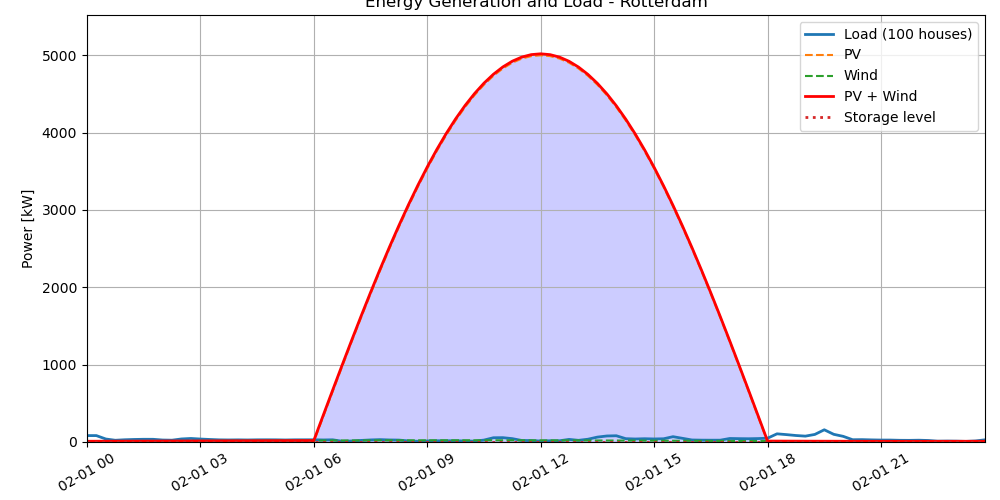

In [5]:
from energy_dashboard_function import run_energy_dashboard
dashboard = run_energy_dashboard()


Run the simulation and wait for it to finish:

In [6]:
from Slider_set_simulation import run_res_simulation
sim, settings, df = run_res_simulation(dashboard)  


        ____                              _ _
       /    \                            (_) |
  ____/      \  _ __ ___   ___  ___  __ _ _| | __
 /    \      / | '_ ` _ \ / _ \/ __|/ _` | | |/ /
/      \____/  | | | | | | (_) \__ \ (_| | |   <
\      /    \  |_| |_| |_|\___/|___/\__,_|_|_|\_\
 \____/      \____
 /    \      /    \     mosaik: 3.5.0
/      \____/      \       API: 3.0.13
\      /    \      /    Python: 3.11.13
 \____/      \____/         OS: Windows-10-10.0.26100-SP0
      \      /            Docs: https://mosaik.readthedocs.io/en/3.5.0/
       \____/     Get in touch: https://github.com/orgs/OFFIS-mosaik/discussions

2026-01-15 11:11:54.127 | INFO     | mosaik.async_scenario:start:420 - Starting "Collector" as "Collector-0" ...


c:\Users\ainet\Desktop\Work\Energy HUB

Simulation updated:
  Dataset: Rotterdam
  PV size: 1250 kW
  Turbines: 2
  Storage: 180.0 kW
CSVload file path: 'data\\load_data.txt'
Exists on disk? -> True
Columns as seen by pandas:
   'Load_data'


2026-01-15 11:12:02.846 | INFO     | mosaik.async_scenario:start:420 - Starting "CSVload" as "CSVload-0" ...


2026-01-15 11:12:04.152 | WARNING  | mosaik.async_scenario:user_warning:342 - c:\Users\ainet\miniconda3\envs\ill-dev\Lib\site-packages\mosaik\adapters.py:98: UserWarning: Simulator CSVload-0 is using an outdated API version, namely 1. It should still work. You can suppress this warning by adding an explicit API version for this simulator in your SimConfig.
2026-01-15 11:12:04.158 | INFO     | mosaik.async_scenario:start:420 - Starting "CSV_pv" as "CSV_pv-0" ...


running extra init
{'CSVload': [Entity(full_id='CSVload-0.time-based_0', model_mock=<mosaik.async_scenario.AsyncModelMock object at 0x000001BC44350110>, children=[])]}


...

flag warning: None
Load dem: 22.8722749
pv: 0.0
wind: 0
Discharge Battery
max discharge: 1.8431999999999986
res load: 22.8722749
Flow Bat: -1.8431999999999986
residual load: 22.8722749
battery flow: -1.8431999999999986
dump: -21.0290749
flag warning: None
Load dem: 19.8255212
pv: 0.0
wind: 0.18946132359281231
Discharge Battery
max discharge: 1.3320000000000003
res load: 19.636059876407188
Flow Bat: -1.3320000000000003
residual load: 19.636059876407188
battery flow: -1.3320000000000003
dump: -18.304059876407187
flag warning: None
Load dem: 19.1650237
pv: 0.0
wind: 0.2978689354283464
Discharge Battery
max discharge: 0.9612000000000013
res load: 18.86715476457165
Flow Bat: -0.9612000000000013
residual load: 18.86715476457165
battery flow: -0.9612000000000013
dump: -17.90595476457165
flag warning: None
Load dem: 21.062873
pv: 0.0
wind: 0.27844902491663376
Discharge Battery
max discharge: 0.6947999999999986
res load: 20.784423975083367
Flow Bat: -0.6947999999999986
residual load: 20.7844239

 99%|█████████▉| 94/95 [00:05<00:00, 17.53steps/s]

flag warning: None
Load dem: 17.5444703
pv: 0.0
wind: 0.3079086303699236
Discharge Battery
max discharge: 0.5021999999999999
res load: 17.236561669630078
Flow Bat: -0.5021999999999999
residual load: 17.236561669630078
battery flow: -0.5021999999999999
dump: -16.73436166963008
flag warning: None
Load dem: 8.8327953
pv: 0.0
wind: 0.28999616058392946
Discharge Battery
max discharge: 0.3635999999999999
res load: 8.542799139416072
Flow Bat: -0.3635999999999999
residual load: 8.542799139416072
battery flow: -0.3635999999999999
dump: -8.179199139416072
flag warning: None
Load dem: 10.1797205
pv: 0.0
wind: 0.2544903371142309
Discharge Battery
max discharge: 0.2628000000000014
res load: 9.92523016288577
Flow Bat: -0.2628000000000014
residual load: 9.92523016288577
battery flow: -0.2628000000000014
dump: -9.662430162885768
flag warning: None
Load dem: 9.009023200000001
pv: 0.0
wind: 0.3140393761536986
Discharge Battery
max discharge: 0.18900000000000078
res load: 8.694983823846304
Flow Bat: -0.1

100%|██████████| 95/95 [00:05<00:00, 16.63steps/s]
2026-01-15 11:12:12.072 | INFO     | mosaik.async_scenario:run:845 - Simulation finished successfully.


flag warning: None
Load dem: 5.9355288
pv: 0.0
wind: 0.36376666715166756
Discharge Battery
max discharge: 0.13680000000000092
res load: 5.571762132848333
Flow Bat: -0.13680000000000092
residual load: 5.571762132848333
battery flow: -0.13680000000000092
dump: -5.434962132848332
flag warning: None
Load dem: 11.6267595
pv: 0.0
wind: 0.44648755583513156
Discharge Battery
max discharge: 0.09899999999999948
res load: 11.180271944164868
Flow Bat: -0.09899999999999948
residual load: 11.180271944164868
battery flow: -0.09899999999999948
dump: -11.081271944164868


Outputs plot:

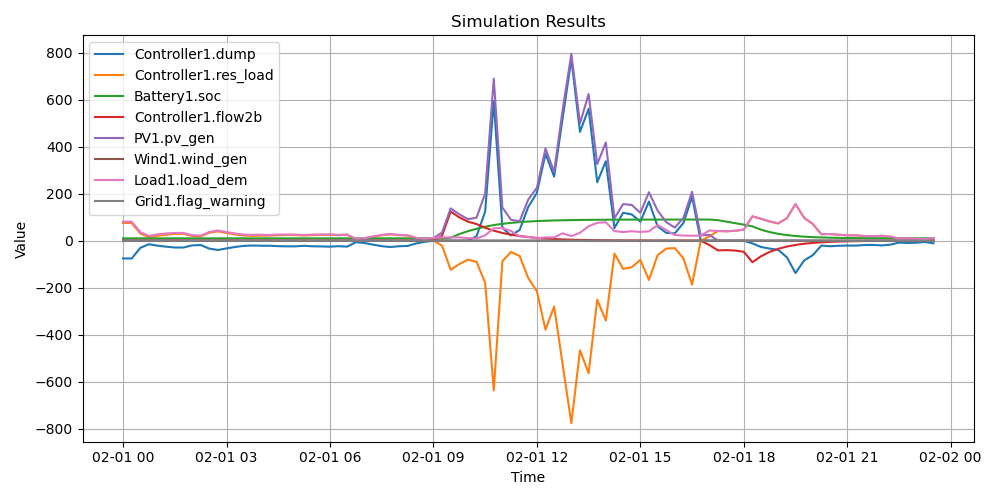

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_simulation_results(
    filepath="out_Tutorial_Renewables.csv",
    variables=None,
    title="Simulation Results",
    figsize=(10,5)
):
    """
    Plot selected variables from Illuminator output CSV.
    
    Parameters
    ----------
    filepath : str
        Path to the output CSV defined in YAML (monitor.file).
    variables : list of str
        List of columns to plot. If None, will show all available numeric columns.
    title : str
        Title of the plot.
    figsize : tuple
        Figure size.
    """

    # Load the data
    df = pd.read_csv(filepath)

    # Detect time column
    time_col = df.columns[0]
    df[time_col] = pd.to_datetime(df[time_col])

    # Autodetect variables if none specified
    if variables is None:
        variables = [c for c in df.columns if c != time_col]

    # Plot
    plt.figure(figsize=figsize)

    for var in variables:
        if var not in df.columns:
            print(f"⚠ Skipping '{var}' (not in dataset)")
            continue
        plt.plot(df[time_col], df[var], label=var)

    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_simulation_results()



Plot the CO2 emissions, the cost of electricity, and a check on grid congestion


BASELINE (Grid only):
  Total Energy Consumed:    -1.02 MWh
  Total Cost:               €-104.05
  Mean Price:               €81.35/MWh

Number of timesteps:        95

✓ Results saved to: electricity_cost_results.csv

PLOTTING ELECTRICITY COST BREAKDOWN


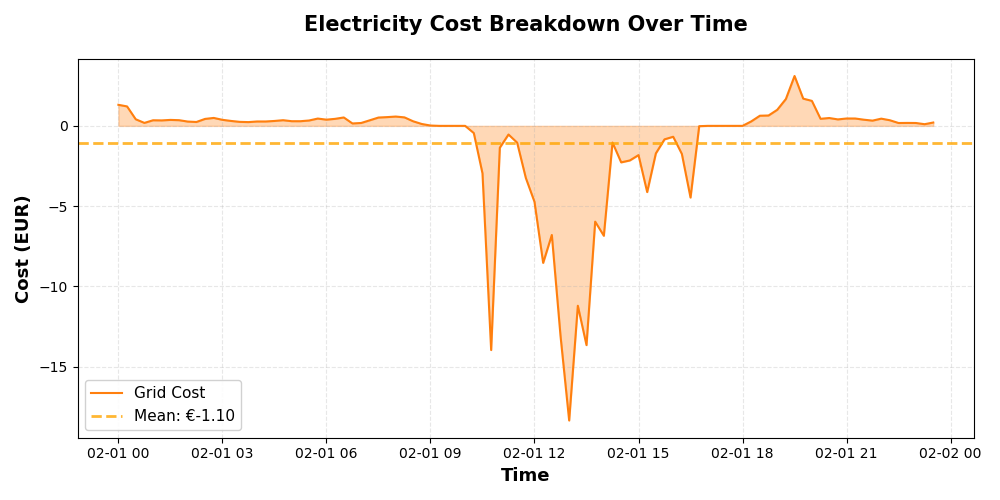

✓ Plot displayed
Total CO2 Emissions:        83.67 kg
                            0.08 tonnes


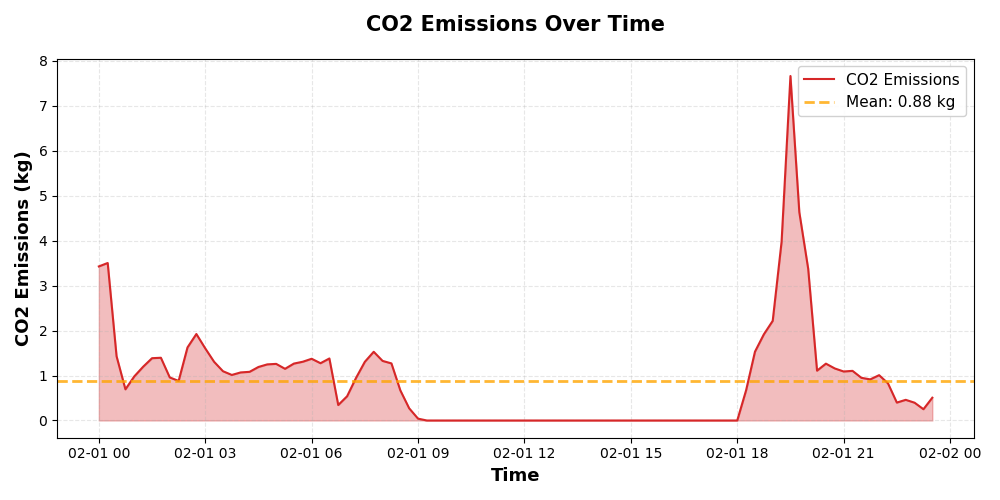

In [8]:
from electricity_cost_calculator_with_mix_plot import calculate_electricity_cost, plot_electricity_cost

results = calculate_electricity_cost(
    price_file='data\GUI_ENERGY_PRICES_202511272300-202511282300.csv',
    consumption_file='out_Tutorial_Renewables.csv',
    consumption_column='Controller1.dump',
    consumption_date_column='date',
    price_date_column='MTU (CET/CEST)',
    price_column='Day-ahead Price (EUR/MWh)',
    output_csv='electricity_cost_results.csv'
)

plot_electricity_cost(results)
figsize=(10, 5)


from complete_co2_workflow import align_dates_and_calculate_co2, plot_co2_emissions

results = align_dates_and_calculate_co2(
    generation_file='data\GENERATION_PER_TYPE_20251125-20251202.csv',
    consumption_file='out_Tutorial_Renewables.csv',
    consumption_column='Controller1.dump',
    consumption_date_column='date'
)

plot_co2_emissions(results)
figsize=(10, 5)


In [9]:
from renewable_electricity_cost_calculator2_improved4 import (
    calculate_renewable_and_grid_costs,
    plot_renewable_mix_costs,
    plot_cumulative_costs
)

In [13]:
# Your slider values
n_pv_panels = dashboard["pv_size_slider"].value      # Number of PV panels
n_wind_turbines = dashboard["n_t_slider"].value       # Number of wind turbines  
battery_capacity = dashboard["storage_slider"].value  # Battery capacity in kWh

# Your file paths
PRICE_FILE = 'data\GUI_ENERGY_PRICES_202511272300-202511282300.csv'
OUTPUT_FILE = 'out_Tutorial_Renewables.csv'

In [14]:
results = calculate_renewable_and_grid_costs(
    # Files
    price_file=PRICE_FILE,
    consumption_file=OUTPUT_FILE,
    renewable_output_file=OUTPUT_FILE,
    
    # Column names (adjust if different)
    consumption_column='Controller1.dump',
    pv_column='PV1.pv_gen',
    wind_column='Wind1.wind_gen',
    consumption_date_column='date',
    price_date_column='MTU (CET/CEST)',
    price_column='Day-ahead Price (EUR/MWh)',
    
    # System configuration (from sliders)
    n_pv=n_pv_panels,
    n_wind=n_wind_turbines,
    battery_capacity_kWh=battery_capacity,
    
    # LCOE parameters (defaults shown - adjust as needed)
    pv_cost_per_panel_EUR=800,
    pv_capacity_per_panel_kW=0.4,
    pv_lifetime_years=25,
    wind_cost_per_turbine_EUR=50000,
    wind_capacity_per_turbine_kW=10,
    wind_lifetime_years=20,
    battery_cost_per_kWh_EUR=600,
    battery_lifetime_years=10,
    discount_rate=0.05,
    
    # Output
    output_csv='./renewable_grid_cost_results.csv'
)


RENEWABLE AND GRID ELECTRICITY COST CALCULATION

Loading data files...
✓ Price data: 96 rows
✓ Consumption data: 95 rows
✓ Renewable generation data: 95 rows

Consumption starts at: 2012-02-01 00:00:00

Aligning price file dates to consumption dates...
✓ Price dates aligned

CALCULATING LEVELIZED COST OF ENERGY (LCOE)

Validating column names...
✓ PV column 'PV1.pv_gen' found
✓ Wind column 'Wind1.wind_gen' found

Simulation period: 0 days
Annualization factor: 1.00

--- CAPITAL COSTS ---
PV System (5 panels):           €4,000.00
Wind System (2 turbines):      €100,000.00
Battery (180.0 kWh):         €108,000.00
TOTAL CAPITAL COST:                €212,000.00

--- PV LCOE ---
Annual generation:                 1,834 kWh/year
Lifetime:                          25 years
LCOE:                              €0.1765/kWh
                                   €176.52/MWh

--- WIND LCOE ---
Annual generation:                 3 kWh/year
Lifetime:                          20 years
LCOE:               


PLOTTING RENEWABLE MIX ELECTRICITY COSTS


KeyError: 'Grid_Cost_EUR'

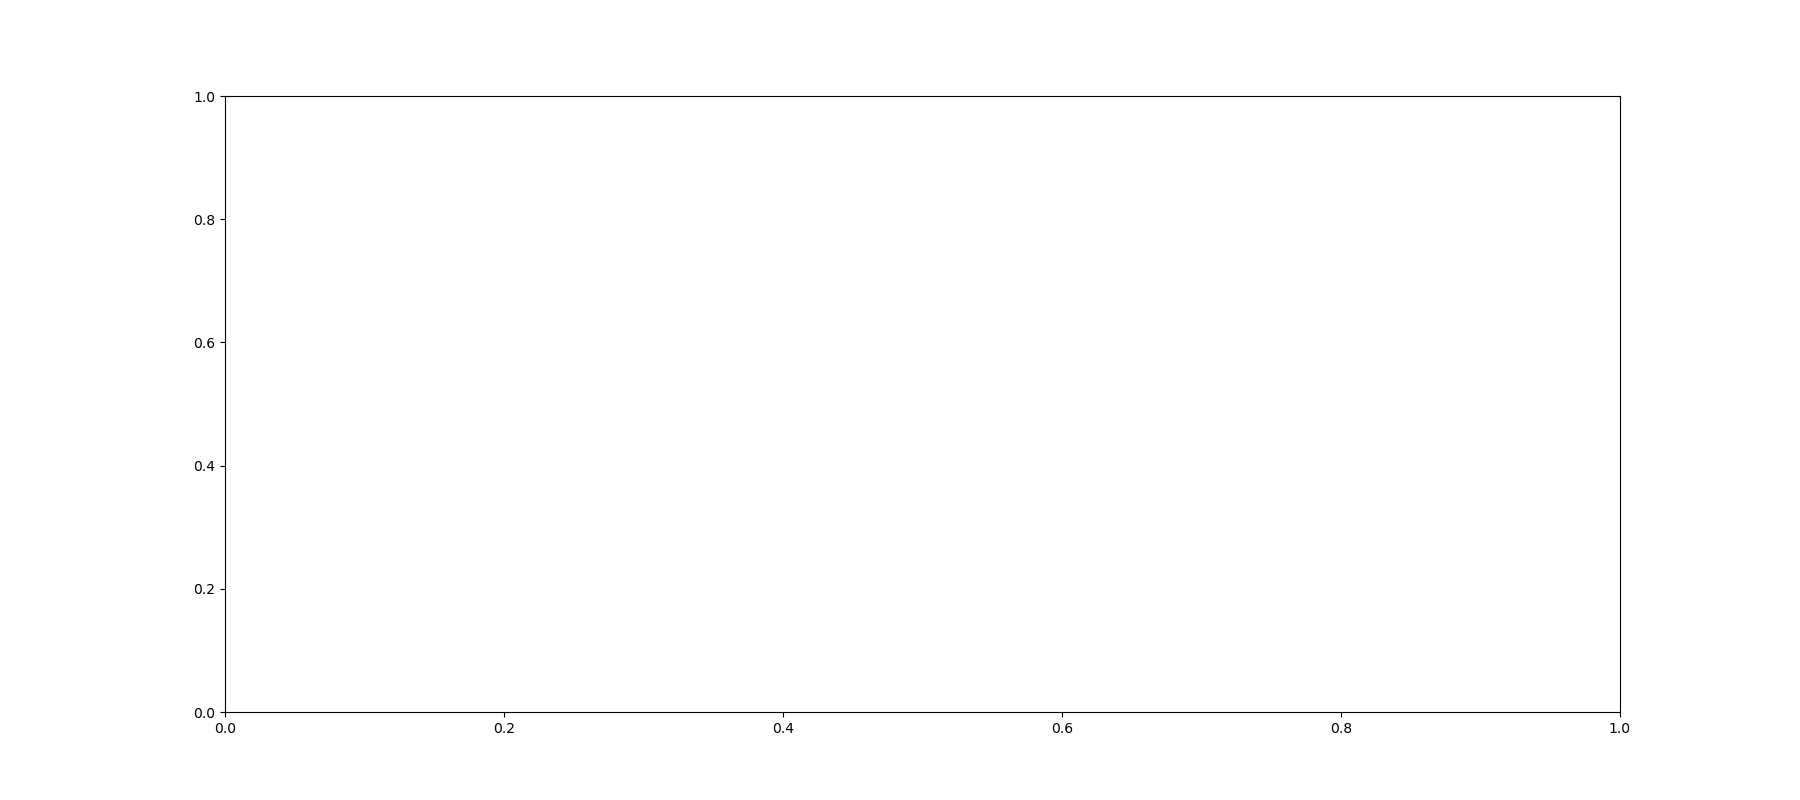

In [12]:
# Plot 1: Renewable mix with stacked costs (different colors for each source)
plot_renewable_mix_costs(results)


Energy mix time dependent: https://transparency.entsoe.eu/generation/actual/perType/generation?appState=%7B%22sa%22%3A%5B%22BZN%7C10YNL----------L%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22CHART%22%2C%22df%22%3A%5B%222026-01-15%22%2C%222026-01-15%22%5D%2C%22tz%22%3A%22CET%22%7D

Intraday day-ahead prices: https://transparency.entsoe.eu/market/energyPrices?appState=%7B%22sa%22%3A%5B%22BZN%7C10YNL----------L%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22CHART%22%2C%22df%22%3A%222026-01-15%22%2C%22tz%22%3A%22CET%22%7D

Readjust the amount of PV's, wind and storage and evaluate the effect of your choice. The simulation results are stored in the pages here, page one has the results for the initial case with no renewables 